# 02_02 · IM BPV：30 / 60 / 120 / 360 交易日窗口对比

只读 `02_01_im_bpv_intraday_seasonality.ipynb` 产出的四份窗口结果，不重算或改写季节因子。窗口单位全部为**交易日**。每个交易日的因子来自此前完整历史日，前 $L$ 个交易日为空。

图表依次展示：覆盖范围 → 同日季节曲线 → 指定分钟随时间的变化 → 季节曲面 → 去季节后的残余时段形状 → 窗口差异与稳定程度。

为了公平比较，效果统计只使用四个窗口都有效的**相同完整交易日及相同 236 个 BPV minute slot**。09:31、09:32、13:01、13:02 没有 BPV contribution，保持为空。午休用分面或分隔线表示，不把午休当成连续一分钟。

默认展示共同可用的全部日期；这些是描述性研究图，不是训练/验证选参或测试绩效结论，不自动评选最佳窗口。若用于参数选择，先在下面明确限制为训练/验证日期，测试集不得参与选择。短窗口通常更敏感、长窗口通常更稳定是待数据观察的性质，不预设谁更好。

输入主键：`trade_date + minute_slot`；`lookback_trading_days` 为 int16；`trade_date` 为 date32，`minute_slot` 为 time64[us]，统计值为 float64，时间戳有时区。下方读取时核对各文件的局部 Arrow Schema、窗口 metadata 和共同源文件摘要。

**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。


In [1]:
import pathlib
import sys
import datetime as dt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")
from config.data_contracts import validate_arrow_table

research_dir = candidate_root / "R01_project_collection/JQ_strategy/draft_experiments"
lookbacks = (30, 60, 120, 360)
comparison_start = None  # 例如 "2024-01-01"；None 表示共同可用区间的起点。
comparison_end = None    # 若用于选参，必须设为训练/验证截止日。
selected_trade_date = None  # 例如 "2026-08-28"；None 使用对比区间最后一天。
tracked_slots = [dt.time(9, 35), dt.time(10, 0), dt.time(14, 55)]
window_colors = {30: "#147D92", 60: "#D08022", 120: "#7357A5", 360: "#BD4358"}
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Microsoft YaHei", "DejaVu Sans"],
    "axes.unicode_minus": False, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.labelsize": 10,
})
print("Python:", sys.executable)

Python: E:\anaconda3\envs\latitude\python.exe


In [2]:
expected_output_schema = pa.schema([
    pa.field("trade_date", pa.date32(), False),
    pa.field("minute_slot", pa.time64("us"), False),
    pa.field("lookback_trading_days", pa.int16(), False),
    pa.field("bpv_contribution", pa.float64()),
    pa.field("bpv_seasonality", pa.float64()),
    pa.field("bpv_adjusted", pa.float64()),
    pa.field("contract_code", pa.string()),
    pa.field("bar_at", pa.timestamp("us", tz="Asia/Shanghai")),
    pa.field("log_return", pa.float64()),
    pa.field("volatility_seasonality", pa.float64()),
    pa.field("return_adjusted", pa.float64()),
    pa.field("history_end_date", pa.date32()),
])
output_by_lookback = {}
seasonality_by_lookback = {}
adjusted_bpv_by_lookback = {}
coverage_rows = []
source_signatures = set()
for lookback in lookbacks:
    output_path = research_dir / f"im_bpv_seasonality_1m_{lookback}td.parquet"
    output_table = pq.read_table(output_path)
    if not output_table.schema.equals(expected_output_schema, check_metadata=False):
        raise TypeError(f"{output_path.name} 的物理 Schema 不兼容")
    metadata = output_table.schema.metadata or {}
    if metadata.get(b"lookback_trading_days") != str(lookback).encode():
        raise ValueError(f"{output_path.name} 的窗口 metadata 不匹配")
    if metadata.get(b"seasonality_scale") != b"variance/BPV" or not metadata.get(b"source_sha256"):
        raise ValueError("缺少尺度或数据来源摘要")
    source_signatures.add((metadata[b"source_sha256"], metadata[b"as_of_at"]))
    output_df = validate_arrow_table(output_table, expected_output_schema).to_pandas()
    if not output_df["lookback_trading_days"].eq(lookback).all():
        raise ValueError("窗口字段与文件名不一致")
    output_df = output_df.set_index(["trade_date", "minute_slot"]).sort_index()
    if not output_df.index.is_unique:
        raise ValueError("分钟输出主键重复")
    seasonality_matrix = output_df["bpv_seasonality"].unstack("minute_slot")
    output_by_lookback[lookback] = output_df
    seasonality_by_lookback[lookback] = seasonality_matrix
    adjusted_bpv_by_lookback[lookback] = output_df["bpv_adjusted"].unstack("minute_slot")
    valid_curve_dates = seasonality_matrix.index[seasonality_matrix.notna().any(axis=1)]
    coverage_rows.append({
        "窗口（交易日）": lookback, "输出行数": len(output_df),
        "预热交易日数": lookback, "可用曲线天数": len(valid_curve_dates),
        "首次可用日期": valid_curve_dates[0] if len(valid_curve_dates) else None,
        "末次可用日期": valid_curve_dates[-1] if len(valid_curve_dates) else None,
    })
if len(source_signatures) != 1:
    raise ValueError("四个文件不是同一来源快照/同次计算，请先重新完整运行产出 notebook")
reference_output_df = output_by_lookback[lookbacks[0]]
for lookback in lookbacks[1:]:
    pd.testing.assert_frame_equal(
        reference_output_df[["contract_code", "bar_at", "log_return", "bpv_contribution"]],
        output_by_lookback[lookback][["contract_code", "bar_at", "log_return", "bpv_contribution"]],
    )
bpv_matrix = reference_output_df["bpv_contribution"].unstack("minute_slot")
trade_dates = bpv_matrix.index
minute_slots = bpv_matrix.columns
coverage_df = pd.DataFrame(coverage_rows).set_index("窗口（交易日）")
display(coverage_df)

,输出行数,预热交易日数,可用曲线天数,首次可用日期,末次可用日期
窗口（交易日）,,,,,
30,238800,30,965,2022-09-05,2026-08-28
60,238800,60,935,2022-10-25,2026-08-28
120,238800,120,875,2023-01-18,2026-08-28
360,238800,360,635,2024-01-15,2026-08-28


## 1. 覆盖范围和公平对比样本

灰色是尚无曲线的日期，彩色是存在季节曲线的日期。横轴以交易日序号等距排列，刻度标注实际日期。长窗口需要更长预热，并不表示那段原始行情不存在。

下方共同样本要求每一天的 236 个非边界位置均有原始 contribution，四个窗口的季节因子均大于零、调整值均有限。不填补、不把缺失当零。所有后续效果图使用这组固定样本。

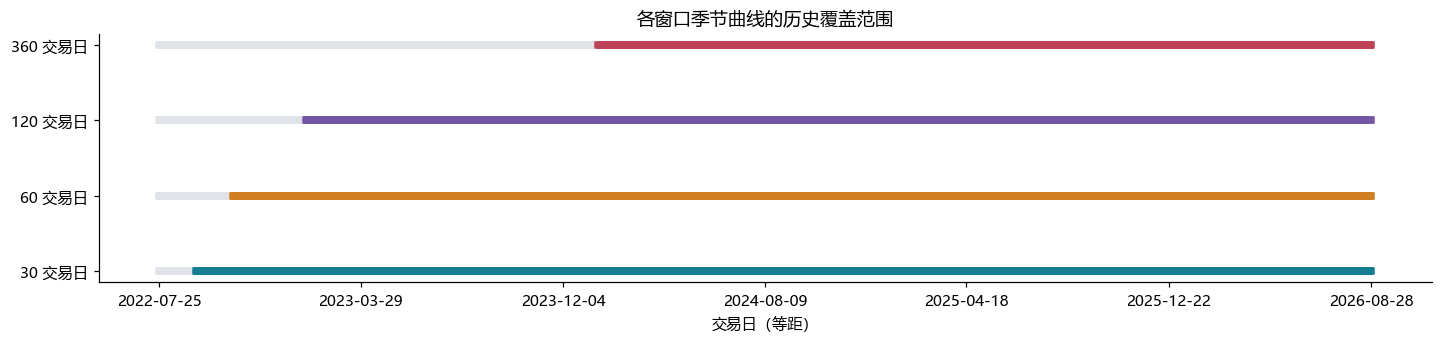

共同样本：2024-01-15 至 2026-08-28，635 个交易日 × 236 个 minute slot
同日曲线展示日期: 2026-08-28


In [3]:
figure, axis = plt.subplots(figsize=(13, 3), layout="constrained")
for row_number, lookback in enumerate(lookbacks):
    available = seasonality_by_lookback[lookback].notna().any(axis=1).to_numpy()
    axis.scatter(np.arange(len(trade_dates)), np.full(len(trade_dates), row_number), color="#E0E3E8", marker="s", s=14)
    axis.scatter(np.flatnonzero(available), np.full(int(available.sum()), row_number), color=window_colors[lookback], marker="s", s=14)
tick_positions = np.linspace(0, len(trade_dates) - 1, 7, dtype=int)
axis.set_xticks(tick_positions, [str(trade_dates[i]) for i in tick_positions])
axis.set_yticks(range(4), [f"{lookback} 交易日" for lookback in lookbacks])
axis.set_title("各窗口季节曲线的历史覆盖范围")
axis.set_xlabel("交易日（等距）")
plt.show()

boundary_slots = [dt.time(9, 31), dt.time(9, 32), dt.time(13, 1), dt.time(13, 2)]
valid_slots = minute_slots[~minute_slots.isin(boundary_slots)]
if len(valid_slots) != 236:
    raise ValueError("分钟结构不符合当前 IM 实验的 236 个有效位置")
common_minute_mask = np.isfinite(bpv_matrix[valid_slots]) & bpv_matrix[valid_slots].ge(0)
for lookback in lookbacks:
    common_minute_mask &= np.isfinite(seasonality_by_lookback[lookback][valid_slots])
    common_minute_mask &= seasonality_by_lookback[lookback][valid_slots].gt(0)
    common_minute_mask &= np.isfinite(adjusted_bpv_by_lookback[lookback][valid_slots])
common_day_mask = common_minute_mask.all(axis=1) & bpv_matrix[valid_slots].sum(axis=1).gt(0)
if comparison_start is not None:
    common_day_mask &= trade_dates >= pd.Timestamp(comparison_start).date()
if comparison_end is not None:
    common_day_mask &= trade_dates <= pd.Timestamp(comparison_end).date()
comparison_dates = trade_dates[common_day_mask]
if not len(comparison_dates):
    raise ValueError("所选范围内没有四窗口共同有效的完整交易日")
plot_date = comparison_dates[-1] if selected_trade_date is None else pd.Timestamp(selected_trade_date).date()
if plot_date not in comparison_dates:
    raise ValueError("展示日期必须属于共同有效样本")
print(f"共同样本：{comparison_dates[0]} 至 {comparison_dates[-1]}，{len(comparison_dates)} 个交易日 × {len(valid_slots)} 个 minute slot")
print("同日曲线展示日期:", plot_date)

## 2. 同一个交易日：四条开盘前已确定的季节曲线

因子 1 是全日有效位置的平均水平；因子 2 表示该分钟在 variance/BPV scale 上约为平均水平的两倍。对收益率调整时使用因子的平方根。

上午和下午分别展示；四个窗口使用相同纵轴。这里只比较同一个目标日，避免把不同日期的市场变化误认成窗口差异。

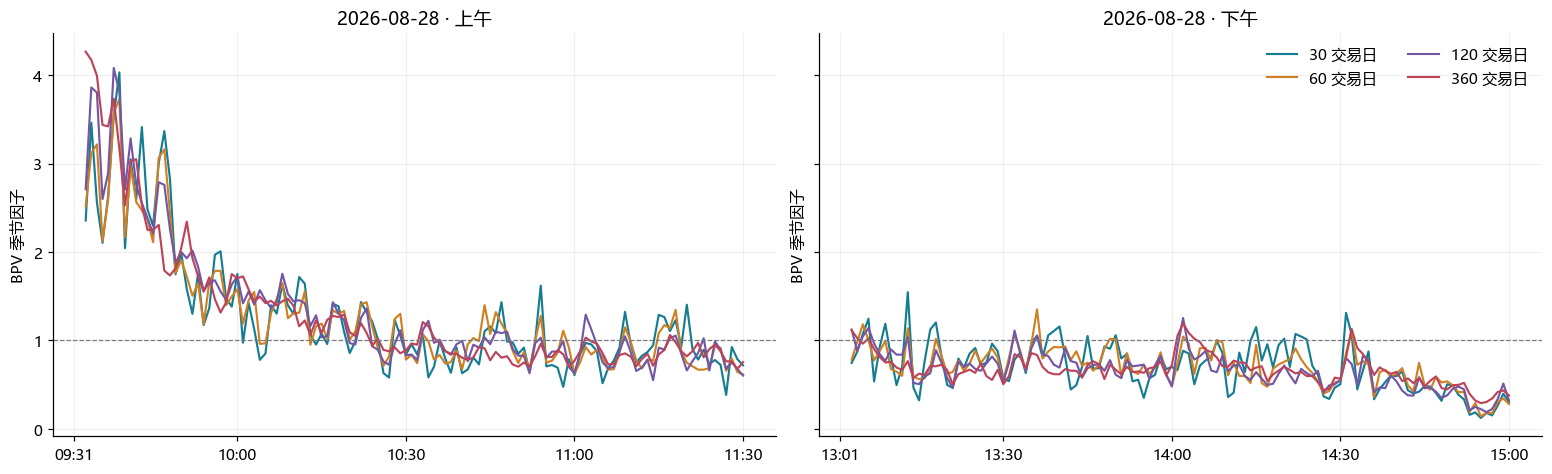

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True, layout="constrained")
for session_number, (start_slot, end_slot) in enumerate([(0, 120), (120, 240)]):
    axis = axes[session_number]
    for lookback in lookbacks:
        curve = seasonality_by_lookback[lookback].loc[plot_date].iloc[start_slot:end_slot]
        axis.plot(np.arange(120), curve.to_numpy(), color=window_colors[lookback], linewidth=1.4, label=f"{lookback} 交易日")
    tick_positions = [0, 29, 59, 89, 119]
    axis.set_xticks(tick_positions, [minute_slots[start_slot+i].strftime("%H:%M") for i in tick_positions])
    axis.axhline(1, color="#747B85", linestyle="--", linewidth=0.8)
    axis.set_title(f"{plot_date} · {'上午' if session_number == 0 else '下午'}")
    axis.set_ylabel("BPV 季节因子")
    axis.grid(alpha=0.18)
axes[1].legend(ncol=2, frameon=False)
plt.show()

## 3. 固定分钟：季节因子如何随交易日更新

每一点都是那一天开盘前已经确定的因子。较快变化可能反映响应更快，也可能意味着估计噪声较大，不能只凭曲线平稳或敏感判断优劣。缺失日期保持空值，绘图不跨缺口补线。

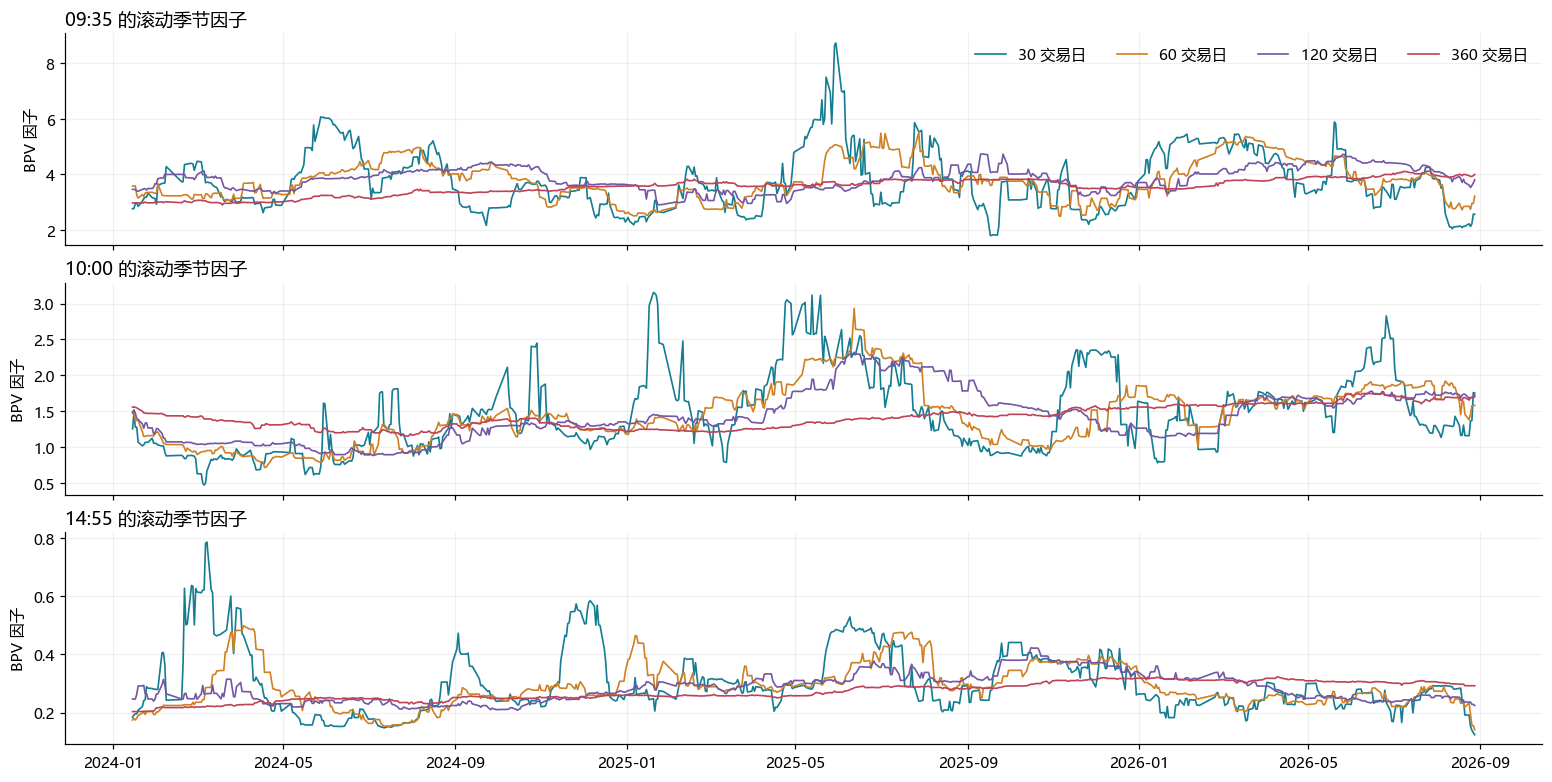

In [5]:
figure, axes = plt.subplots(len(tracked_slots), 1, figsize=(14, 7), sharex=True, layout="constrained")
visible_dates = trade_dates[(trade_dates >= comparison_dates[0]) & (trade_dates <= comparison_dates[-1])]
for axis, minute_slot in zip(np.atleast_1d(axes), tracked_slots):
    for lookback in lookbacks:
        factor_series = seasonality_by_lookback[lookback].loc[visible_dates, minute_slot].where(common_day_mask.loc[visible_dates])
        axis.plot(pd.to_datetime(visible_dates), factor_series.to_numpy(), color=window_colors[lookback], linewidth=1.1, label=f"{lookback} 交易日")
    axis.set_title(f"{minute_slot.strftime('%H:%M')} 的滚动季节因子", loc="left")
    axis.set_ylabel("BPV 因子")
    axis.grid(alpha=0.18)
axes[0].legend(ncol=4, frameon=False)
plt.show()

## 4. 日内季节曲面：共同色标

横轴为一天中的 minute slot，纵轴为交易日，午休以虚线分隔。四幅图使用相同对数色标；色标限于共同样本因子的 1%–99% 分位数，超界颜色饱和，**只影响显示，不修改数据或统计**。灰色表示缺失或未进入共同样本。

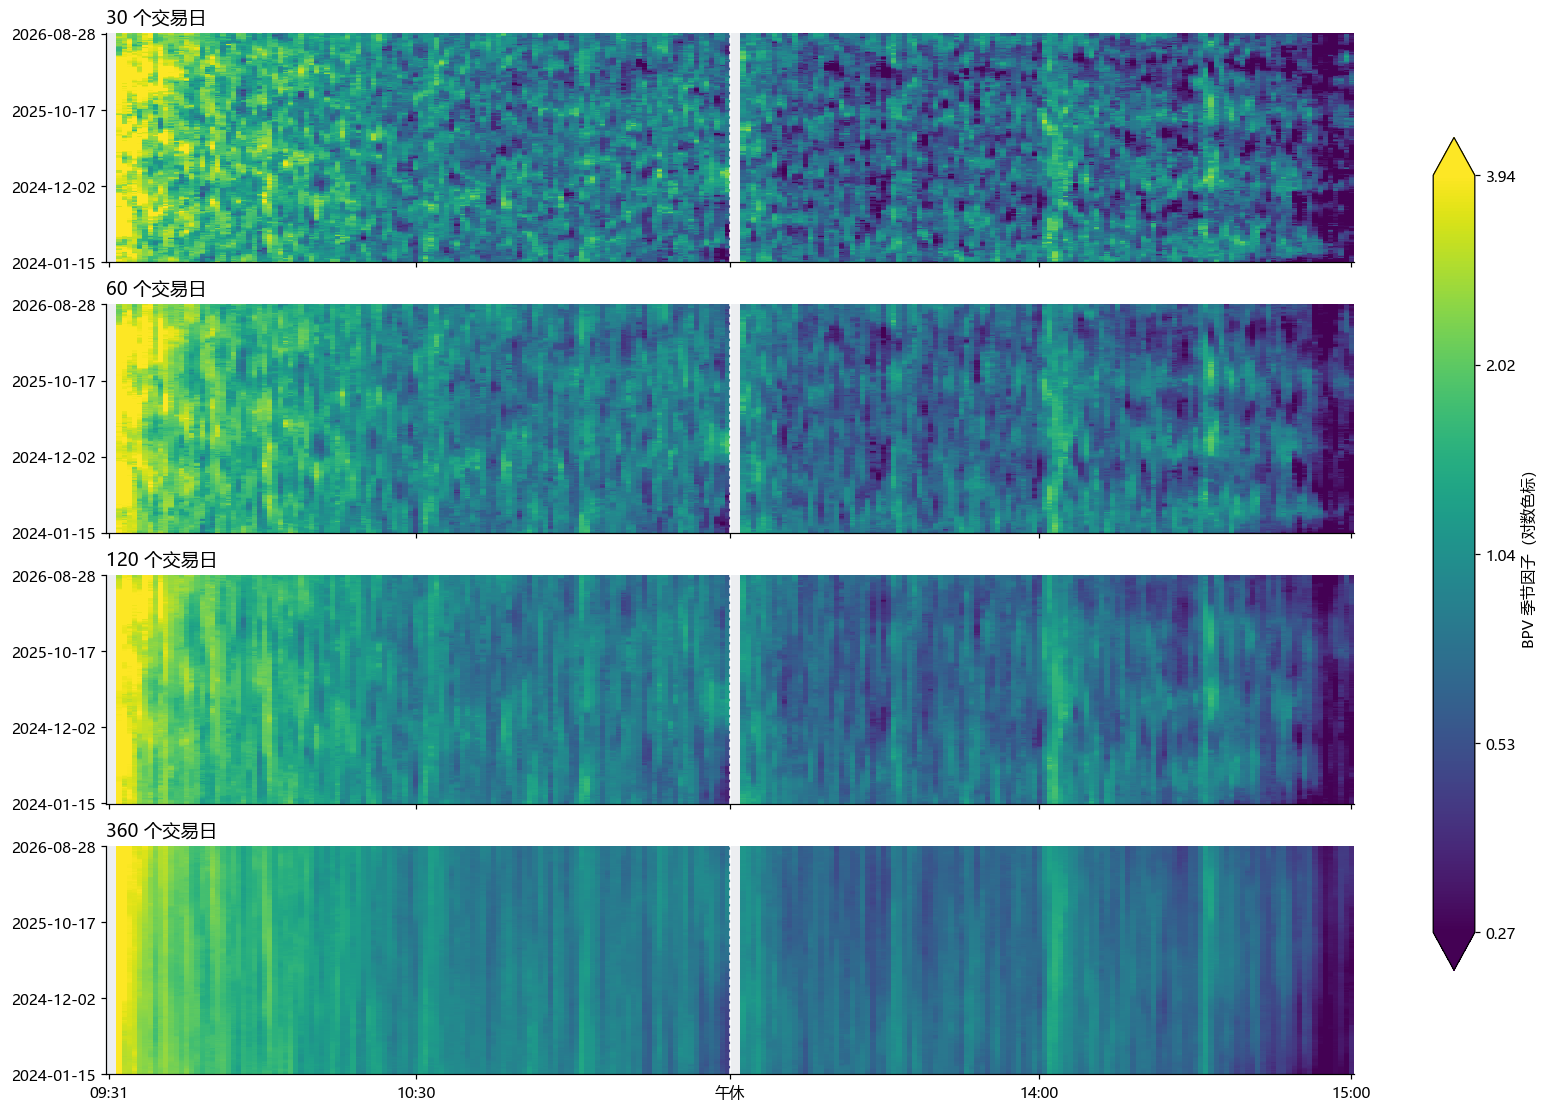

共同色标范围：0.273 至 3.942；其外数值仅在显示上饱和


In [6]:
heatmap_values = np.concatenate([
    seasonality_by_lookback[lookback].loc[comparison_dates, valid_slots].to_numpy().ravel()
    for lookback in lookbacks
])
color_lower, color_upper = np.quantile(heatmap_values, [0.01, 0.99])
if color_upper <= color_lower:
    color_upper = color_lower * 1.01
color_norm = LogNorm(vmin=color_lower, vmax=color_upper)
color_map = plt.get_cmap("viridis").copy()
color_map.set_bad("#ECEEF1")
figure, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, layout="constrained")
for axis, lookback in zip(axes, lookbacks):
    heatmap_matrix = seasonality_by_lookback[lookback].loc[visible_dates].where(common_day_mask.loc[visible_dates], axis=0)
    heatmap_image = axis.imshow(heatmap_matrix.to_numpy(), aspect="auto", origin="lower", cmap=color_map, norm=color_norm, interpolation="nearest")
    axis.axvline(119.5, color="white", linestyle="--", linewidth=1)
    date_ticks = np.linspace(0, len(visible_dates)-1, 4, dtype=int)
    axis.set_yticks(date_ticks, [str(visible_dates[i]) for i in date_ticks])
    axis.set_title(f"{lookback} 个交易日", loc="left")
slot_ticks = [0, 59, 119.5, 179, 239]
axes[-1].set_xticks(slot_ticks, ["09:31", "10:30", "午休", "14:00", "15:00"])
colorbar = figure.colorbar(heatmap_image, ax=axes, label="BPV 季节因子（对数色标）", extend="both", shrink=0.8)
color_ticks = np.geomspace(color_lower, color_upper, 5)
colorbar.set_ticks(color_ticks, labels=[f"{value:.2f}" for value in color_ticks])
colorbar.minorticks_off()
plt.show()
print(f"共同色标范围：{color_lower:.3f} 至 {color_upper:.3f}；其外数值仅在显示上饱和")

## 5. 去季节后是否还存在固定的时段形状

在同一组完整日期上，分别把原始 $b$ 和各窗口调整后的 $b^{adj}$ **重新按日均值归一化**，再对每个 slot 跨日取中位数，最后把这条描述曲线归一到分钟均值 1。

这一步只用于收盘后的效果诊断，避免高波动日主导图形；不会回写因子，也不是当天可用特征。曲线越接近水平线，表示该样本的典型残余时段差异越小；不代表预测能力、收益或测试集表现更好。

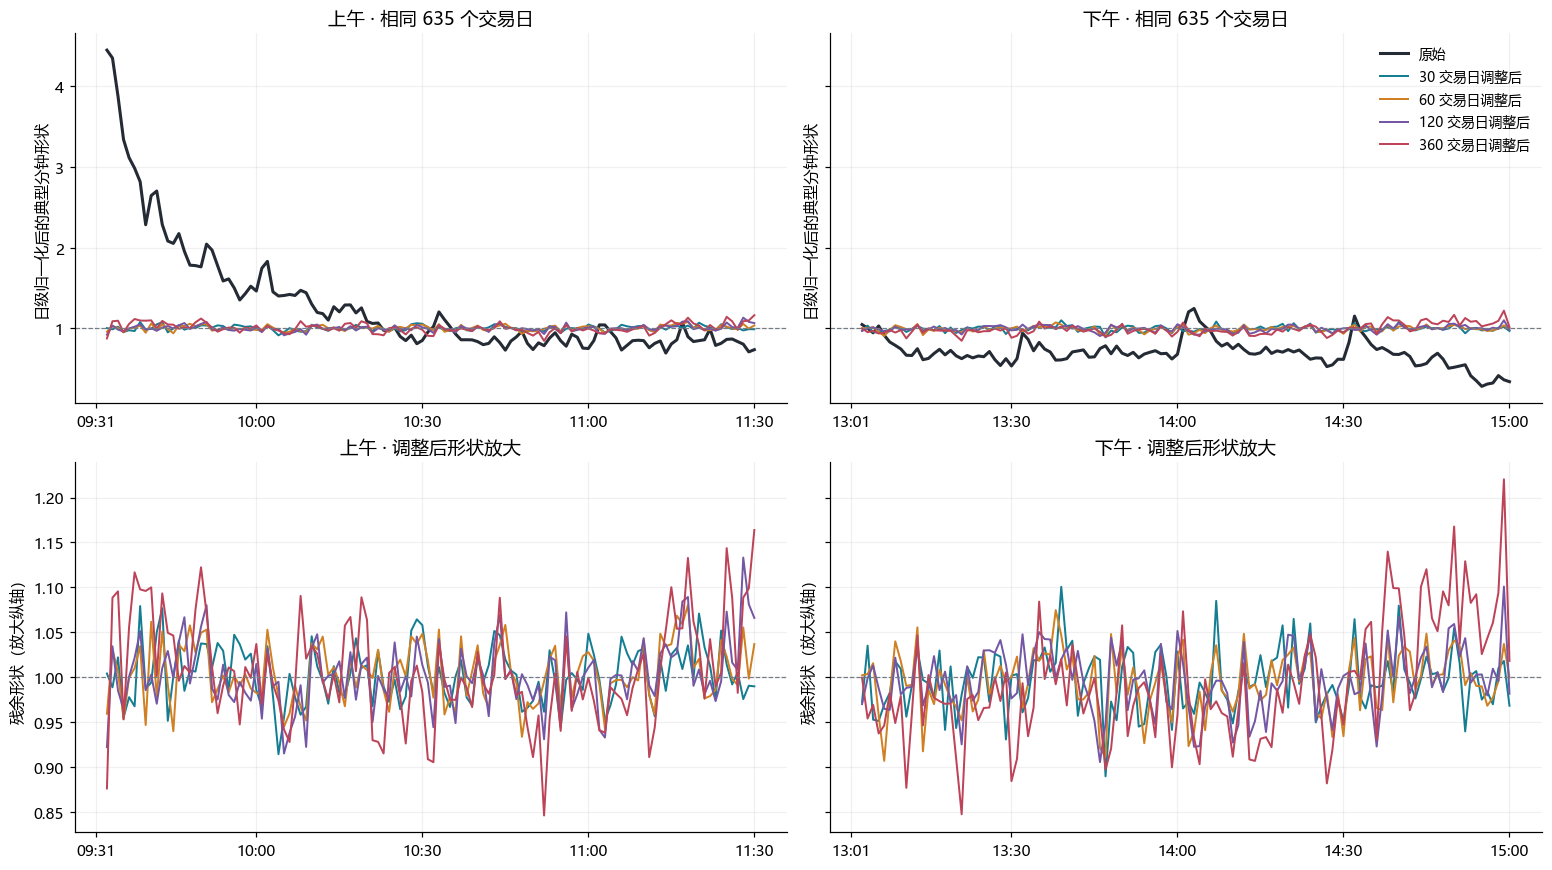

In [7]:
profile_by_window = {}
profile_inputs = {"原始": bpv_matrix.loc[comparison_dates, valid_slots]}
for lookback in lookbacks:
    profile_inputs[f"{lookback} 交易日"] = adjusted_bpv_by_lookback[lookback].loc[comparison_dates, valid_slots]
for profile_name, contribution_matrix in profile_inputs.items():
    normalized_daily_matrix = contribution_matrix.div(contribution_matrix.mean(axis=1), axis=0)
    median_profile = normalized_daily_matrix.median(axis=0)
    profile_by_window[profile_name] = median_profile / median_profile.mean()
profile_df = pd.DataFrame(profile_by_window).reindex(minute_slots)
figure, axes = plt.subplots(2, 2, figsize=(14, 7.8), sharey="row", layout="constrained")
for session_number, (start_slot, end_slot) in enumerate([(0, 120), (120, 240)]):
    axis = axes[0, session_number]
    axis.plot(np.arange(120), profile_df["原始"].iloc[start_slot:end_slot], color="#252B35", linewidth=2, label="原始")
    for lookback in lookbacks:
        axis.plot(np.arange(120), profile_df[f"{lookback} 交易日"].iloc[start_slot:end_slot], color=window_colors[lookback], linewidth=1.3, label=f"{lookback} 交易日调整后")
    tick_positions = [0, 29, 59, 89, 119]
    axis.set_xticks(tick_positions, [minute_slots[start_slot+i].strftime("%H:%M") for i in tick_positions])
    axis.axhline(1, color="#747B85", linestyle="--", linewidth=0.8)
    axis.set_title(f"{'上午' if session_number == 0 else '下午'} · 相同 {len(comparison_dates)} 个交易日")
    axis.set_ylabel("日级归一化后的典型分钟形状")
    axis.grid(alpha=0.18)
axes[0, 1].legend(fontsize=9, frameon=False)
for session_number, (start_slot, end_slot) in enumerate([(0, 120), (120, 240)]):
    axis = axes[1, session_number]
    for lookback in lookbacks:
        axis.plot(np.arange(120), profile_df[f"{lookback} 交易日"].iloc[start_slot:end_slot], color=window_colors[lookback], linewidth=1.3)
    tick_positions = [0, 29, 59, 89, 119]
    axis.set_xticks(tick_positions, [minute_slots[start_slot+i].strftime("%H:%M") for i in tick_positions])
    axis.axhline(1, color="#747B85", linestyle="--", linewidth=0.8)
    axis.set_title(f"{'上午' if session_number == 0 else '下午'} · 调整后形状放大")
    axis.set_ylabel("残余形状（放大纵轴）")
    axis.grid(alpha=0.18)
plt.show()

## 6. 定量比较：残余时段差异、日际变化与窗口差异

“形状偏离 1 的平均绝对值”和“形状变异系数”描述上图的残余时段差异。日际变化是**相邻正式交易日**曲线的平均绝对变化，仅在前后两日均属于共同样本时计入，不跨缺失日连接。

窗口差异矩阵为同日同 slot 的 `平均 |log(s₁/s₂)|`，对称且对角线为零。它衡量窗口结果相差多少，不提供优劣排序。所有量均为描述性统计，没有自动选参。

,共同交易日数,形状偏离1的平均绝对值,形状变异系数,相邻交易日因子平均绝对变化
序列,,,,
原始,635,0.38225,0.60678,NaN
30 交易日,635,0.02639,0.03293,0.06118
60 交易日,635,0.02724,0.03347,0.03101
120 交易日,635,0.02837,0.03681,0.01563
360 交易日,635,0.04786,0.06173,0.00531


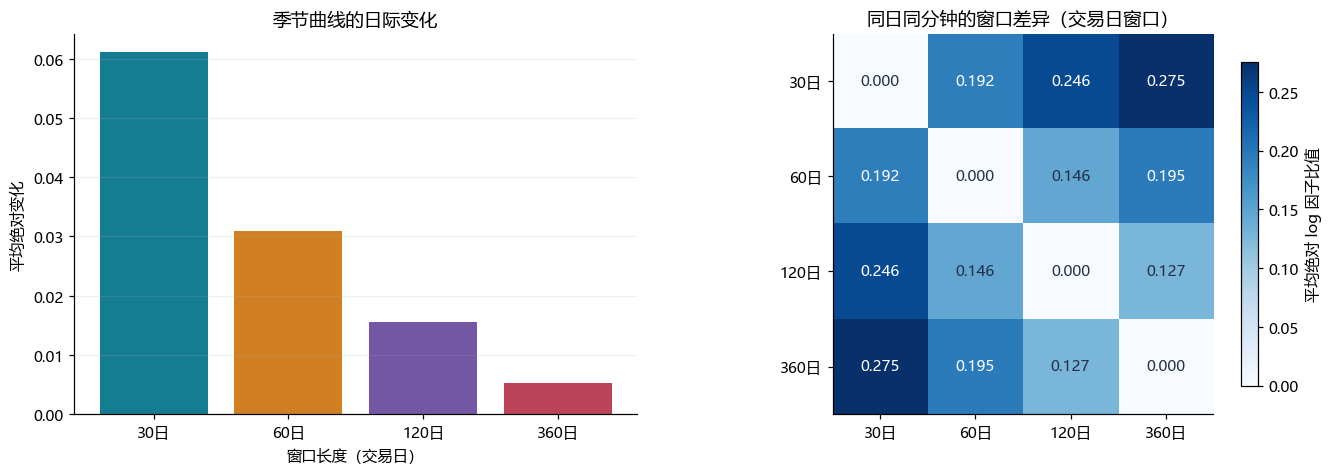

图表完成；只读四个结果文件。修改第一个代码单元格的日期/分钟参数后，从头运行即可切换对比范围。


In [8]:
metric_rows = []
for profile_name, profile_series in profile_by_window.items():
    metric_rows.append({
        "序列": profile_name,
        "共同交易日数": len(comparison_dates),
        "形状偏离1的平均绝对值": float((profile_series - 1).abs().mean()),
        "形状变异系数": float(profile_series.std(ddof=0) / profile_series.mean()),
        "相邻交易日因子平均绝对变化": np.nan,
    })
metrics_df = pd.DataFrame(metric_rows).set_index("序列")
paired_day_mask = common_day_mask & common_day_mask.shift(1, fill_value=False)
for lookback in lookbacks:
    daily_change = seasonality_by_lookback[lookback][valid_slots].diff().abs().mean(axis=1)
    metrics_df.loc[f"{lookback} 交易日", "相邻交易日因子平均绝对变化"] = daily_change.loc[paired_day_mask].mean()
display(metrics_df.round(5))

window_distance_df = pd.DataFrame(index=lookbacks, columns=lookbacks, dtype="float64")
for first_lookback in lookbacks:
    for second_lookback in lookbacks:
        first_factors = seasonality_by_lookback[first_lookback].loc[comparison_dates, valid_slots].to_numpy()
        second_factors = seasonality_by_lookback[second_lookback].loc[comparison_dates, valid_slots].to_numpy()
        window_distance_df.loc[first_lookback, second_lookback] = np.abs(np.log(first_factors / second_factors)).mean()
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
bar_values = metrics_df.loc[[f"{lookback} 交易日" for lookback in lookbacks], "相邻交易日因子平均绝对变化"]
axes[0].bar([f"{lookback}日" for lookback in lookbacks], bar_values, color=[window_colors[lookback] for lookback in lookbacks])
axes[0].set_title("季节曲线的日际变化")
axes[0].set_xlabel("窗口长度（交易日）")
axes[0].set_ylabel("平均绝对变化")
axes[0].grid(axis="y", alpha=0.18)
distance_image = axes[1].imshow(window_distance_df.to_numpy(), cmap="Blues", vmin=0)
axes[1].set_xticks(range(4), [f"{lookback}日" for lookback in lookbacks])
axes[1].set_yticks(range(4), [f"{lookback}日" for lookback in lookbacks])
axes[1].set_title("同日同分钟的窗口差异（交易日窗口）")
for row_number in range(4):
    for column_number in range(4):
        value = window_distance_df.iloc[row_number, column_number]
        axes[1].text(column_number, row_number, f"{value:.3f}", ha="center", va="center", color="white" if value > window_distance_df.to_numpy().max()*0.6 else "#243047")
figure.colorbar(distance_image, ax=axes[1], label="平均绝对 log 因子比值", shrink=0.85)
plt.show()
print("图表完成；只读四个结果文件。修改第一个代码单元格的日期/分钟参数后，从头运行即可切换对比范围。")